In [29]:
import numpy as np
#import matplotlib; matplotlib.use('QtAgg')
import matplotlib.pyplot as plt
import pandas as pd
import sys
sys.path.append('C:/Users/pierr/OneDrive - IPSA/Documents/IPSA/Aero 4/Stage A4/BIRA IASB Bruxelles/code/git-internship/')

from GSEP_extended import build_GSEP_extended
from dataset_reading import load_srs_combine_complete

# Functions

In [30]:
def histo(GSEP, srs, title, sort_by = 'Ratio (%)'):
    value_counts_gsep = GSEP.value_counts(normalize=True)*100
    value_counts_srs = srs.value_counts(normalize=True)*100
    ratio = (GSEP.value_counts()/srs.value_counts())*100

    df = pd.DataFrame({
        'SRS': value_counts_srs,
        'GSEP': value_counts_gsep, 
        'Ratio (%)': ratio
    })
    df = df.sort_values(sort_by, ascending=False)

    ax = df.plot(kind='bar', color=['grey', 'navy', 'cornflowerblue'], figsize=(10, 6))
    plt.title(title)
    plt.grid(alpha = 0.3)
    plt.show()

def histo_multi(GSEP_all, GSEP_over_S1, GSEP_over_S2, GSEP_over_S3, srs, title, sort_by='Ratio all GSEP'):
    value_counts_gsep_all = GSEP_all.value_counts(normalize=True)*100
    value_counts_gsep_over_s1 = GSEP_over_S1.value_counts(normalize=True) * 100
    value_counts_gsep_over_s2 = GSEP_over_S2.value_counts(normalize=True) * 100
    value_counts_gsep_over_s3 = GSEP_over_S3.value_counts(normalize=True) * 100

    value_counts_srs = srs.value_counts(normalize=True) * 100

    ratio_all = (GSEP_all.value_counts() / srs.value_counts()) * 100
    ratio_1 = (GSEP_over_S1.value_counts() / srs.value_counts()) * 100
    ratio_2 = (GSEP_over_S2.value_counts() / srs.value_counts()) * 100
    ratio_3 = (GSEP_over_S3.value_counts() / srs.value_counts()) * 100

    df = pd.DataFrame({
        'SRS': value_counts_srs,
        'GSEP all' : value_counts_gsep_all, 
        'GSEP >= S1': value_counts_gsep_over_s1,
        'GSEP >= S2': value_counts_gsep_over_s2,
        'GSEP >= S3': value_counts_gsep_over_s3,
        'Ratio all GSEP' : ratio_all,
        'Ratio >= S1 (%)': ratio_1,
        'Ratio >= S2 (%)': ratio_2,
        'Ratio >= S3 (%)': ratio_3
    })
    df = df.sort_values(sort_by, ascending=False)
    a = df[sort_by].to_string()
    print(a)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

    # Graphique du haut : valeurs normalisées
    df[['SRS', 'GSEP all', 'GSEP >= S1', 'GSEP >= S2', 'GSEP >= S3']].plot(
        kind='bar', ax=ax1, color=['grey', 'navy', 'darkgoldenrod', 'darkorange', 'darkred']
    )
    ax1.set_title(title)
    ax1.set_ylabel('Répartition (%)')
    ax1.grid(alpha=0.3)

    # Graphique du bas : ratios
    df[['Ratio all GSEP', 'Ratio >= S1 (%)', 'Ratio >= S2 (%)', 'Ratio >= S3 (%)']].plot(
        kind='bar', ax=ax2, color=['navy', 'darkgoldenrod', 'darkorange', 'darkred']
    )
    ax2.set_title('Ratio [SEP event by AR per day]')
    ax2.set_ylabel('Ratio (%)')
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
    return a 

# Data importation

In [31]:
date_a = pd.Timestamp('1996-01-01')
date_b = pd.Timestamp('2017-09-10')

GSEP = build_GSEP_extended()
GSEP['timestamp'] = pd.to_datetime(GSEP['timestamp'])
GSEP = GSEP[GSEP['timestamp'].between(date_a, date_b)]

GSEP_S1 = GSEP[GSEP['>= S1']==1]
GSEP_S2 = GSEP[GSEP['>= S2']==1]
GSEP_S3 = GSEP[GSEP['>= S3']==1]

srs_combine_complete = load_srs_combine_complete()
srs_combine_complete['DATETIME'] = pd.to_datetime(srs_combine_complete['DATETIME'])
srs_combine_complete = srs_combine_complete[srs_combine_complete['DATETIME'].between(date_a, date_b)]

line 1 over 433
line 2 over 433
line 3 over 433
line 4 over 433
line 5 over 433
line 6 over 433
line 7 over 433
line 8 over 433
line 9 over 433
line 10 over 433
line 11 over 433
line 12 over 433
line 13 over 433
line 14 over 433
line 15 over 433
line 16 over 433
line 17 over 433
line 18 over 433
line 19 over 433
line 20 over 433
line 21 over 433
line 22 over 433
line 23 over 433
line 24 over 433
line 25 over 433
line 26 over 433
line 27 over 433
line 28 over 433
line 29 over 433
line 30 over 433
line 31 over 433
line 32 over 433
line 33 over 433
line 34 over 433
line 35 over 433
line 36 over 433
line 37 over 433
line 38 over 433
line 39 over 433
line 40 over 433
line 41 over 433
line 42 over 433
line 43 over 433
line 44 over 433
line 45 over 433
line 46 over 433
line 47 over 433
line 48 over 433
line 49 over 433
line 50 over 433
line 51 over 433
line 52 over 433
line 53 over 433
line 54 over 433
line 55 over 433
line 56 over 433
line 57 over 433
line 58 over 433
line 59 over 433
line 6

In [32]:
srs_combine_complete = srs_combine_complete.rename(columns={'Z': 'AR_Mcintosh_class'})
srs_combine_complete['AR_Mcintosh_class'] = srs_combine_complete['AR_Mcintosh_class'].str.upper()

srs_combine_complete = srs_combine_complete.rename(columns={'Mag_type': 'hale_class'})
srs_combine_complete['hale_class'] = srs_combine_complete['hale_class'].str.upper()

srs_combine_complete['AR_Mcintosh_Z'] = srs_combine_complete['AR_Mcintosh_class'].str[0]
srs_combine_complete['AR_Mcintosh_p'] = srs_combine_complete['AR_Mcintosh_class'].str[1]
srs_combine_complete['AR_Mcintosh_c'] = srs_combine_complete['AR_Mcintosh_class'].str[2]

srs_combine_complete.head()

,DATETIME,AR_number,Location,Lo,Area,AR_Mcintosh_class,LL,NN,hale_class,AR_Mcintosh_Z,AR_Mcintosh_p,AR_Mcintosh_c
0,1996-01-02 00:30:00,7935,N11W06,205,10,BXO,8,4,BETA,B,X,O
1,1996-01-02 00:30:00,7937,S09E49,150,0,AXX,1,1,ALPHA,A,X,X
2,1996-01-03 00:30:00,7934,S08W60,245,0,AXX,0,1,ALPHA,A,X,X
3,1996-01-03 00:30:00,7935,N11W15,200,0,AXX,1,2,ALPHA,A,X,X
4,1996-01-03 00:30:00,7937,S08E35,150,0,AXX,0,1,ALPHA,A,X,X


# McIntosh Classification

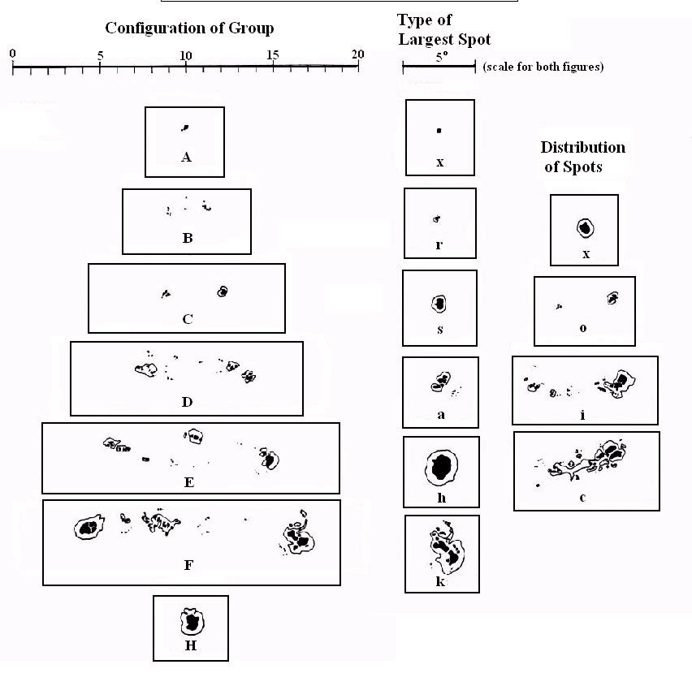

## Entire McInshore 3-letters classification

DSC    7.407407
CKI    7.142857
DKC    6.849315
FKC    6.575342
EKC    5.118110
DHC    4.761905
EHC    4.545455
DKI    4.417671
FHC    4.347826
DKO    3.846154
EHI    3.174603
EKO    2.857143
EKI    2.823529
CKO    1.648352
FSO    1.515152
FKI    1.507538
DAC    1.421801
FAI    1.298701
EAC    1.162791
EAI    1.038062
DHO    0.961538
CAI    0.909091
CHO    0.854701
DSI    0.813008
HKX    0.775194
ESI    0.740741
HHX    0.662252
EAO    0.597907
CAO    0.594943
DAI    0.317125
DAO    0.248139
CSO    0.216383
CRO    0.213523
DSO    0.175901
HSX    0.175824
HAX    0.148258
HRX    0.139276
AXX    0.060551
BXO    0.025368
BXI         NaN
CHI         NaN
CKC         NaN
CRI         NaN
CSI         NaN
DHI         NaN
DRC         NaN
DRI         NaN
DRO         NaN
EHO         NaN
ERI         NaN
ERO         NaN
ESC         NaN
ESO         NaN
FAC         NaN
FAO         NaN
FHI         NaN
FHO         NaN
FKO         NaN
FRO         NaN
FSC         NaN
FSI         NaN
HSO         NaN
HXX     

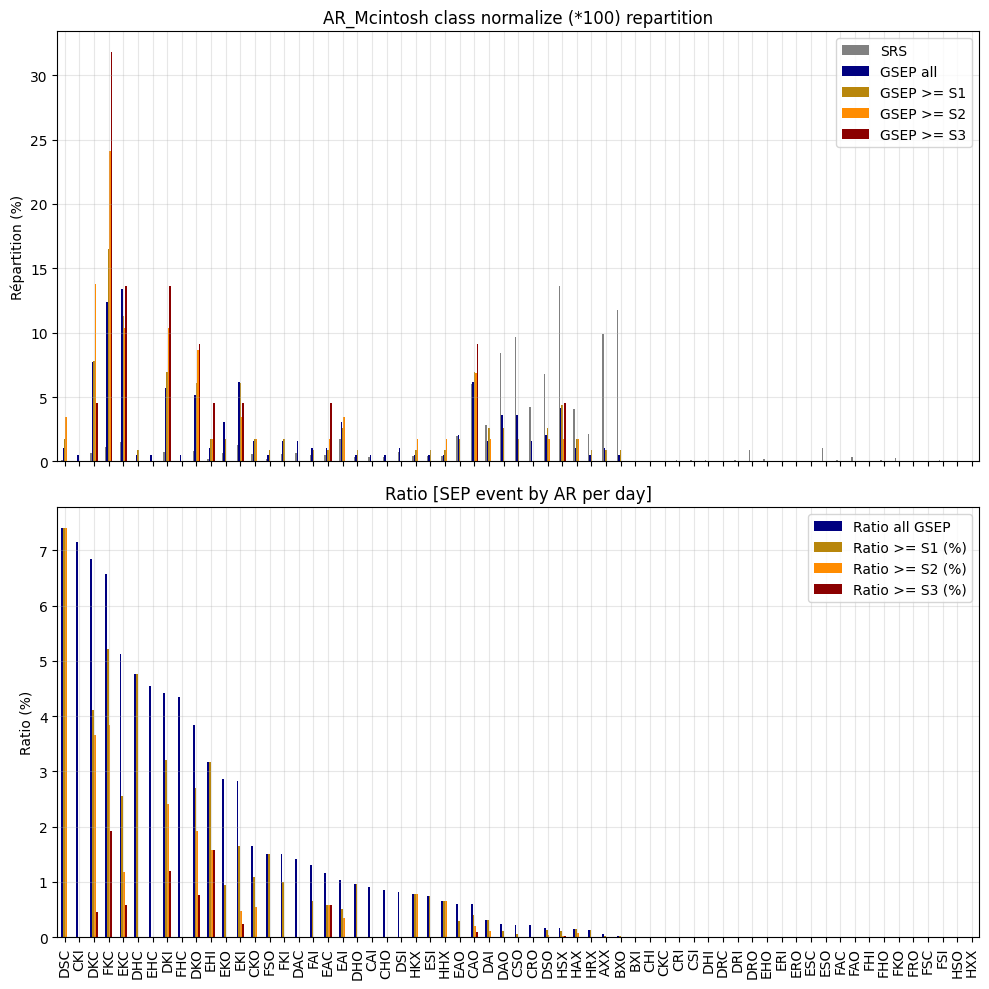

In [33]:
a = histo_multi(GSEP['AR_Mcintosh'], GSEP_S1['AR_Mcintosh'], GSEP_S2['AR_Mcintosh'], GSEP_S3['AR_Mcintosh'], srs_combine_complete['AR_Mcintosh_class'], 'AR_Mcintosh class normalize (*100) repartition') 

In [34]:
print(a)

DSC    7.407407
CKI    7.142857
DKC    6.849315
FKC    6.575342
EKC    5.118110
DHC    4.761905
EHC    4.545455
DKI    4.417671
FHC    4.347826
DKO    3.846154
EHI    3.174603
EKO    2.857143
EKI    2.823529
CKO    1.648352
FSO    1.515152
FKI    1.507538
DAC    1.421801
FAI    1.298701
EAC    1.162791
EAI    1.038062
DHO    0.961538
CAI    0.909091
CHO    0.854701
DSI    0.813008
HKX    0.775194
ESI    0.740741
HHX    0.662252
EAO    0.597907
CAO    0.594943
DAI    0.317125
DAO    0.248139
CSO    0.216383
CRO    0.213523
DSO    0.175901
HSX    0.175824
HAX    0.148258
HRX    0.139276
AXX    0.060551
BXO    0.025368
BXI         NaN
CHI         NaN
CKC         NaN
CRI         NaN
CSI         NaN
DHI         NaN
DRC         NaN
DRI         NaN
DRO         NaN
EHO         NaN
ERI         NaN
ERO         NaN
ESC         NaN
ESO         NaN
FAC         NaN
FAO         NaN
FHI         NaN
FHO         NaN
FKO         NaN
FRO         NaN
FSC         NaN
FSI         NaN
HSO         NaN
HXX     

## Z parameter - Group configuration

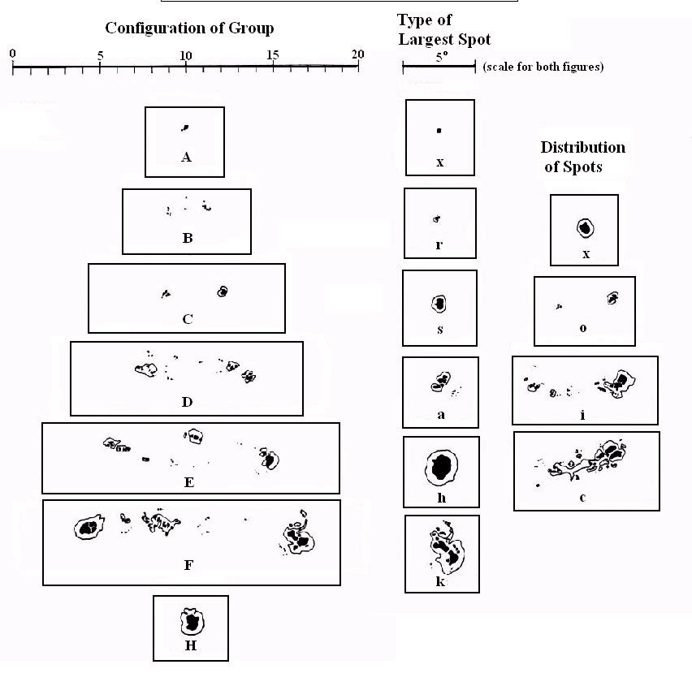

AR_Mcintosh_Z
F    2.772809
E    1.855288
D    0.761585
C    0.391061
H    0.188433
A    0.060551
B    0.025253


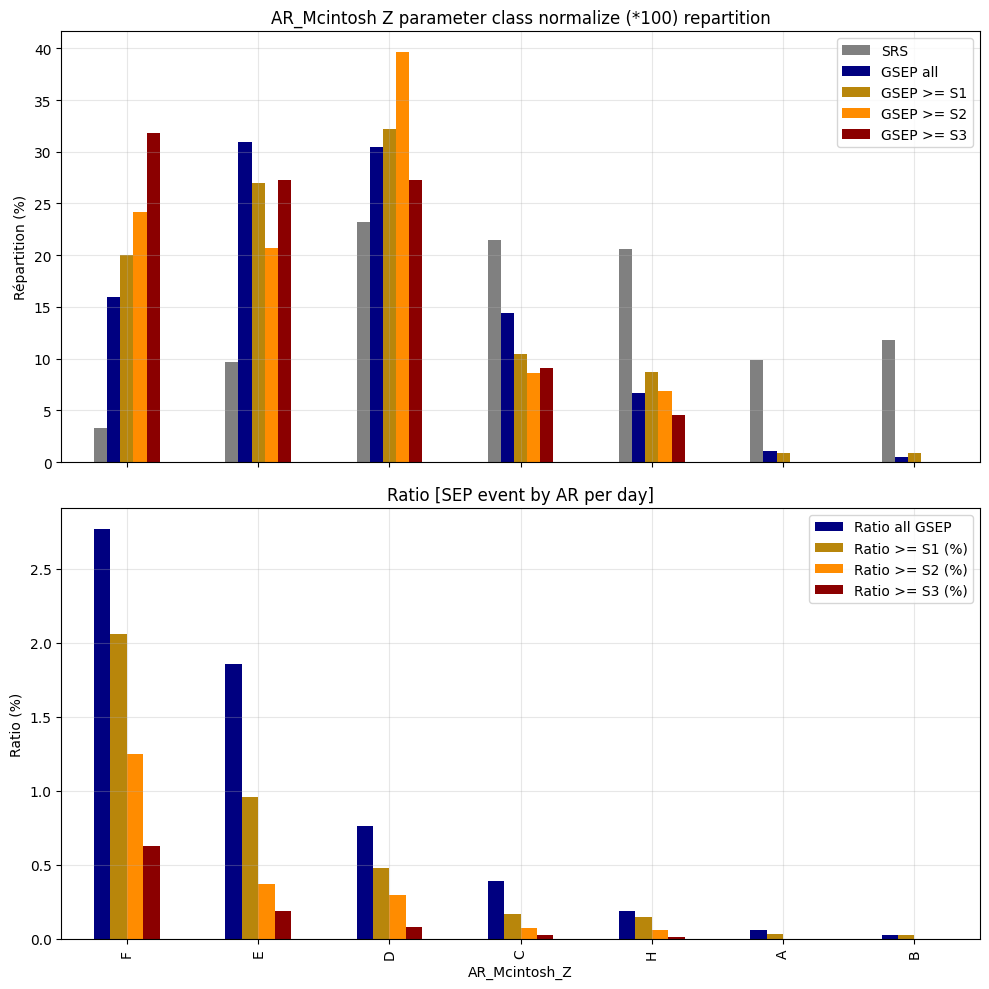

'AR_Mcintosh_Z\nF    2.772809\nE    1.855288\nD    0.761585\nC    0.391061\nH    0.188433\nA    0.060551\nB    0.025253'

In [35]:
histo_multi(GSEP['AR_Mcintosh_Z'], GSEP_S1['AR_Mcintosh_Z'], GSEP_S2['AR_Mcintosh_Z'], GSEP_S3['AR_Mcintosh_Z'], srs_combine_complete['AR_Mcintosh_Z'], 'AR_Mcintosh Z parameter class normalize (*100) repartition') 

## p parameter - Largest Spot Type

AR_Mcintosh_p
K    3.924317
H    1.236476
A    0.457965
S    0.227562
R    0.160064
X    0.041300


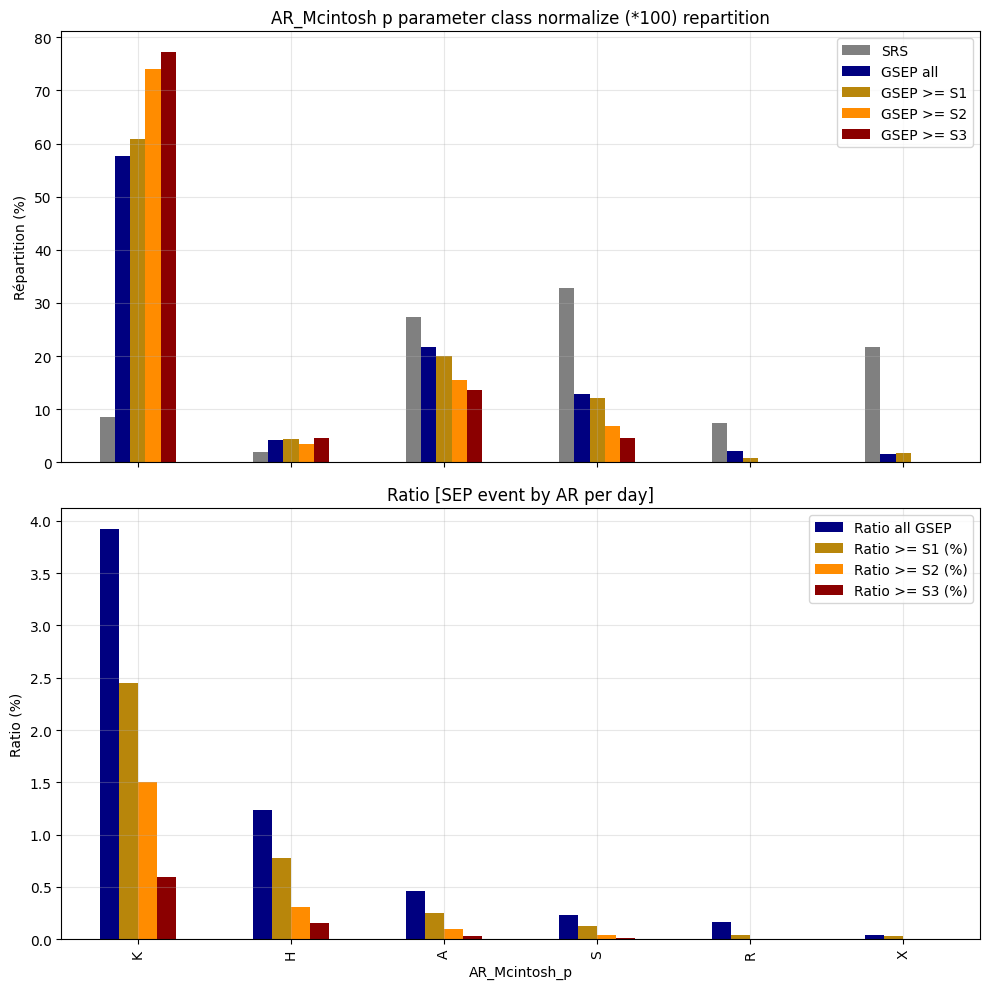

'AR_Mcintosh_p\nK    3.924317\nH    1.236476\nA    0.457965\nS    0.227562\nR    0.160064\nX    0.041300'

In [36]:
histo_multi(GSEP['AR_Mcintosh_p'], GSEP_S1['AR_Mcintosh_p'], GSEP_S2['AR_Mcintosh_p'], GSEP_S3['AR_Mcintosh_p'], srs_combine_complete['AR_Mcintosh_p'], 'AR_Mcintosh p parameter class normalize (*100) repartition') 

## c parameter - Spots distribution

AR_Mcintosh_c
C    4.584352
I    1.326100
O    0.328479
X    0.147044


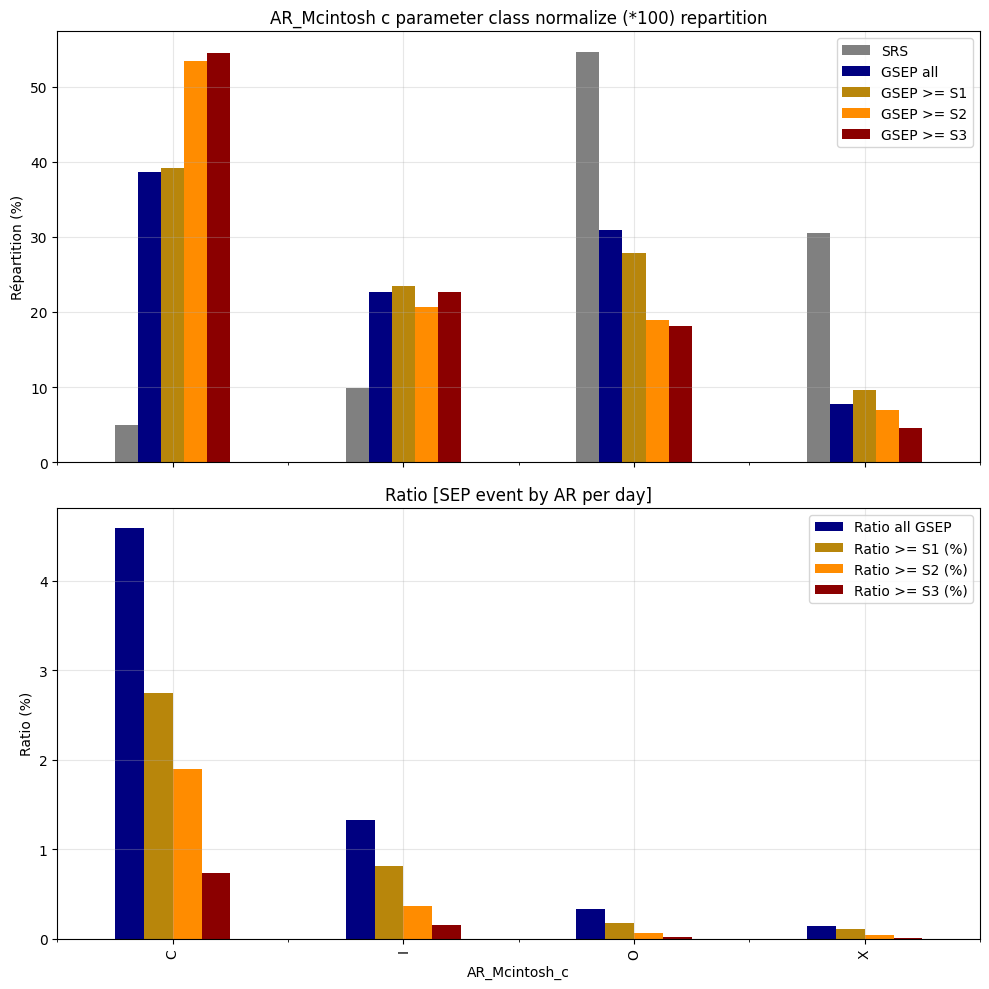

'AR_Mcintosh_c\nC    4.584352\nI    1.326100\nO    0.328479\nX    0.147044'

In [37]:
histo_multi(GSEP['AR_Mcintosh_c'], GSEP_S1['AR_Mcintosh_c'], GSEP_S2['AR_Mcintosh_c'], GSEP_S3['AR_Mcintosh_c'], srs_combine_complete['AR_Mcintosh_c'], 'AR_Mcintosh c parameter class normalize (*100) repartition') 

# Hale Classification

In [38]:
GSEP.columns.tolist()

['sep_index',
 'pp_index',
 'cdaw_sep_id',
 'timestamp',
 'cdaw_start_time',
 'cdaw_max_time',
 'cdaw_evn_max',
 'cme_id',
 'cme_launch_time',
 'cme_1st_app_time',
 'lasco_cme_width',
 'p_cme_width',
 'lasco_linear_speed',
 'p_cme_speed',
 'fl_id',
 'fl_start_time',
 'fl_peak_time',
 'fl_rise_time',
 'fl_lon',
 'fl_lat',
 'fl_goes_class',
 'noaa_ar',
 'noaa_ar_uncertain',
 'harpnum',
 'noaa_pf10MeV',
 'ppf_gt10MeV',
 'ppf_gt30MeV',
 'ppf_gt60MeV',
 'ppf_gt100MeV',
 'fluence_gt10MeV',
 'fluence_gt30MeV',
 'fluence_gt60MeV',
 'fluence_gt100MeV',
 'gsep_pf_gt10MeV',
 'gsep_max_time',
 'gsep_fluence_gt10MeV',
 'm_type2_onset_time',
 'dh_type2_onset_time',
 'start_fr',
 'noaa-sep_flag',
 'Inst_category',
 'Comments',
 'Notes',
 'Fe_e_p_shock_notes',
 'gsep_notes',
 'slice_start',
 'slice_end',
 'Flag',
 'fl_goes_xray',
 'AR_Location',
 'AR_Lo',
 'AR_Area',
 'AR_Mcintosh',
 'AR_LL',
 'AR_NN',
 'AR_Hale',
 'AR_Hale_int',
 'AR_Mcintosh_int',
 'AR_Mcintosh_Z',
 'AR_Mcintosh_p',
 'AR_Mcintosh_c'

In [39]:
srs_combine_complete.columns.tolist()

['DATETIME',
 'AR_number',
 'Location',
 'Lo',
 'Area',
 'AR_Mcintosh_class',
 'LL',
 'NN',
 'hale_class',
 'AR_Mcintosh_Z',
 'AR_Mcintosh_p',
 'AR_Mcintosh_c']

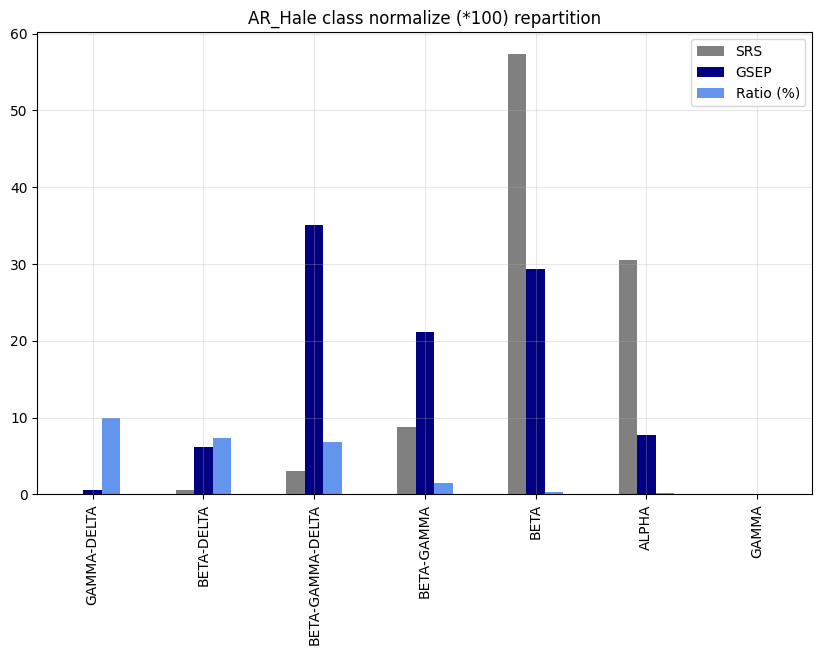

In [40]:
histo(GSEP['AR_Hale'], srs_combine_complete['hale_class'], 'AR_Hale class normalize (*100) repartition' , sort_by = 'Ratio (%)')

GAMMA-DELTA         10.000000
BETA-DELTA           7.272727
BETA-GAMMA-DELTA     6.827309
BETA-GAMMA           1.407001
BETA                 0.297604
ALPHA                0.147362
GAMMA                     NaN


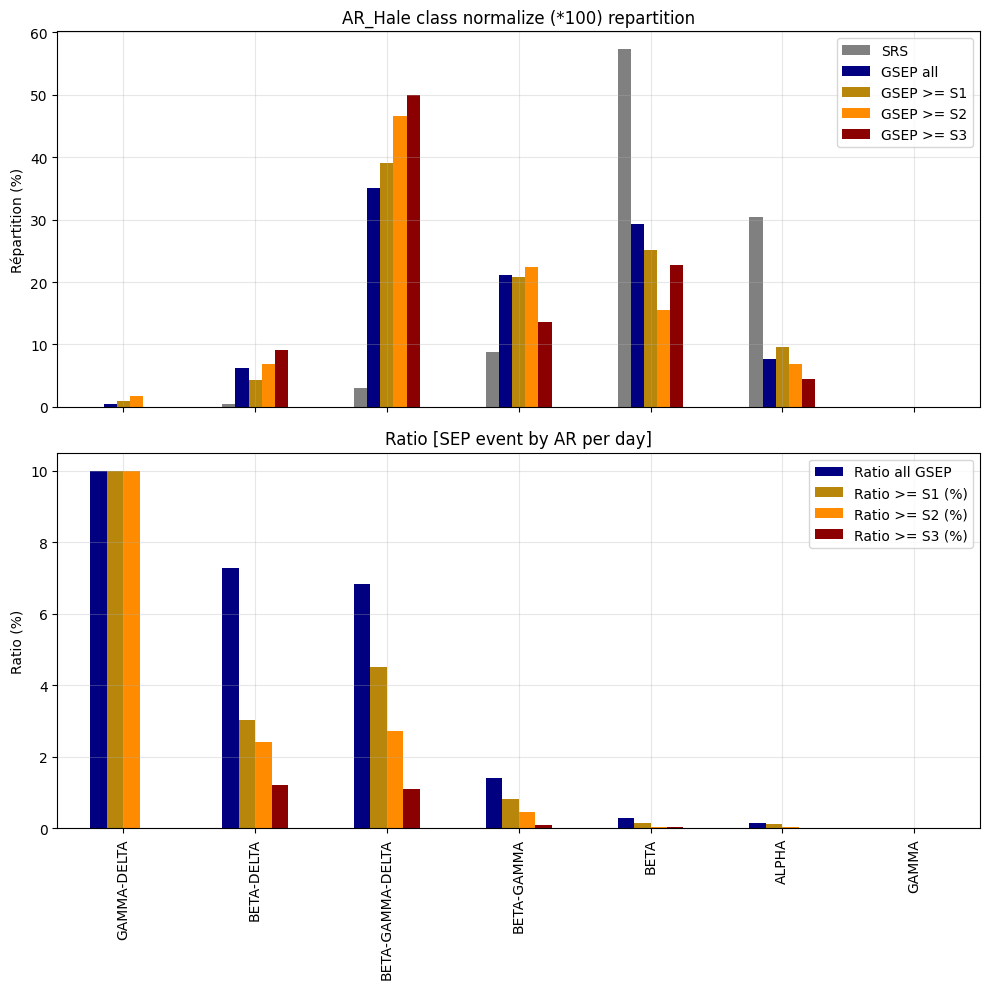

'GAMMA-DELTA         10.000000\nBETA-DELTA           7.272727\nBETA-GAMMA-DELTA     6.827309\nBETA-GAMMA           1.407001\nBETA                 0.297604\nALPHA                0.147362\nGAMMA                     NaN'

In [41]:
histo_multi(GSEP['AR_Hale'], GSEP_S1['AR_Hale'], GSEP_S2['AR_Hale'], GSEP_S3['AR_Hale'], srs_combine_complete['hale_class'], 'AR_Hale class normalize (*100) repartition')